In [145]:
%pip install numpy
%pip install scipy
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn

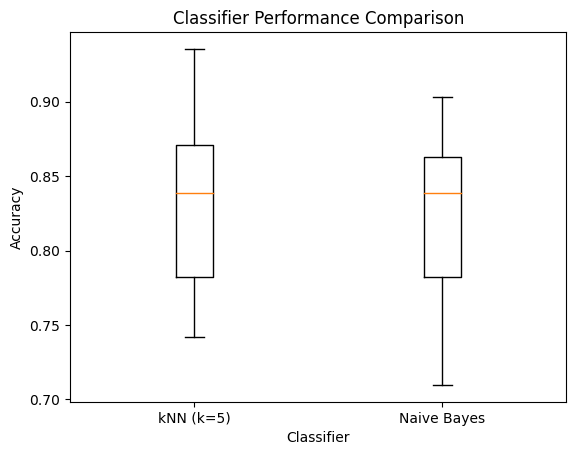

In [146]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
from scipy.io import arff
from sklearn.preprocessing import LabelEncoder

# Load the ARFF dataset
data, meta = arff.loadarff('column_diagnosis.arff')
df = pd.DataFrame(data)

# The last column contains the class labels
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Convert categorical labels to integers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)


# Initialize classifiers
knn_classifier = KNeighborsClassifier(n_neighbors=5)
nb_classifier = GaussianNB()

# Define the cross-validation strategy (for this excercise, StratifiedKFold was used)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

# Apply cross-validation and get accuracies for k-NN and Naive Bayes
knn_scores = cross_val_score(knn_classifier, x, y, cv=cv)
nb_scores = cross_val_score(nb_classifier, x, y, cv=cv)

# Plot two boxplots  with the fold accuracies for each classifier
plt.boxplot([knn_scores, nb_scores], labels=['kNN (k=5)', 'Naive Bayes'])
plt.xlabel('Classifier')
plt.ylabel('Accuracy')
plt.title('Classifier Performance Comparison')
plt.show()




In [147]:
from scipy import stats

res = stats.ttest_rel(knn_scores, nb_scores, alternative='greater')

print(res)

'''
Given the p-value of 0.19, one cannot reject the null hypothesis at common significance levels.
This suggests that there isn't enough evidence to conclude that one classifier is significantly better than the other, which is supported by
the fact that the t-statistic is relatively small. Therefore, we cannot assert whether the hypothesis is true or not.
'''

TtestResult(statistic=0.9214426752509264, pvalue=0.19042809062064092, df=9)


"\nGiven the p-value of 0.19, one cannot reject the null hypothesis at common significance levels.\nThis suggests that there isn't enough evidence to conclude that one classifier is significantly better than the other, which is supported by\nthe fact that the t-statistic is relatively small. Therefore, we cannot assert whether the hypothesis is true or not.\n"

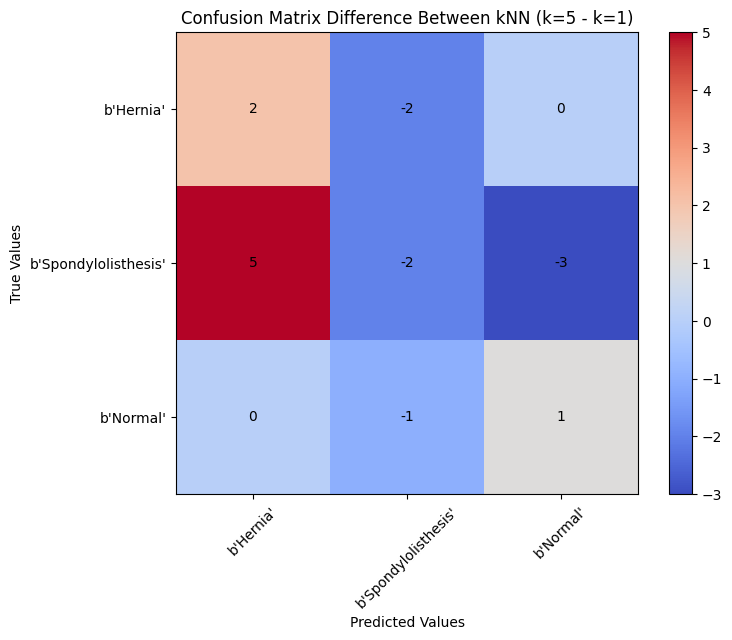

In [148]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

# Load the ARFF dataset
data, meta = arff.loadarff('column_diagnosis.arff')
df = pd.DataFrame(data)

# Assuming the last column contains the class labels
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Convert categorical labels to integers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Initialize kNN classifiers with k=1 and k=5
knn_classifier_k1 = KNeighborsClassifier(n_neighbors=1)
knn_classifier_k5 = KNeighborsClassifier(n_neighbors=5)

# Initialize StratifiedKFold with 10 splits
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

# Initialize lists to store confusion matrices
confusion_matrices_k1 = []
confusion_matrices_k5 = []

# Iterate through the splits
for train_index, test_index in skf.split(X, y):
    # Split the data into training and testing sets
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Train the k-NN classifiers
    knn_classifier_k1.fit(X_train, y_train)
    knn_classifier_k5.fit(X_train, y_train)
    
    # Generate confusion matrices for k=1 and k=5
    confusion_matrix_k1 = confusion_matrix(y_test, knn_classifier_k1.predict(X_test))
    confusion_matrix_k5 = confusion_matrix(y_test, knn_classifier_k5.predict(X_test))
    
    # Append the confusion matrices to their respective lists
    confusion_matrices_k1.append(confusion_matrix_k1)
    confusion_matrices_k5.append(confusion_matrix_k5)


# Calculate the difference between the confusion matrices
confusion_matrix_diff = sum(confusion_matrices_k5) - sum(confusion_matrices_k1)

# Plot the difference matrix
plt.figure(figsize=(8, 6))
im = plt.imshow(confusion_matrix_diff, cmap='coolwarm', interpolation='nearest')
plt.colorbar(im)
plt.title('Confusion Matrix Difference Between kNN (k=5 - k=1)')


# Set x and y labels dynamically based on unique class labels
class_labels = df.iloc[:, -1].unique()
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.xticks(range(len(class_labels)), class_labels, rotation=45)
plt.yticks(range(len(class_labels)), class_labels)

# Add the value of each cell to the plot
for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        plt.text(j, i, str(confusion_matrix_diff[i, j]), ha="center", va="center", color="black")

plt.show()


In [149]:
'''
The kNN model with k=1 is quite sensitive to outliers or unusual data points. It makes decisions based solely on the closest neighbor, so if that neighbor happens to be an 
unusual case, it might lead to incorrect predictions. In contrast, the KNN model with k=5 is more robust when it comes to dealing with outliers. 
It takes into account the opinions of the five closest neighbors, which helps smooth out any influence from individual outliers. 
Even if one of the nearest neighbors is an unusual case, it's less likely to significantly affect the overall classification.

With this is mind, we can conclude that, the first kNN model, with k=1, tends to incorrectly predict a higher number of cases for the 'Hernia' condition. 
Essentially, it thinks more people have hernias than they actually do. On the other hand, the second KNN model, with k=5, often fails to predict cases of 'Spondylolisthesis'. 
In other words, it misses identifying quite a few instances where this condition is actually present. 

Overall, the kNN model with k=5 seems to perform better compared to the one with k=1 for this dataset.
'''

'\nThe graphical representation will elucidate the disparities between the confusion matrices when employing k-Nearest Neighbors classifiers \nwith k-values of 1 and 5. This visualization serves as a tool for understanding the implications of varying k-values on the classification outcomes.\n'

In [150]:
'''
Assumption of Independence: The Naive Bayes algorithm operates under the presumption that features are mutually independent when conditioned on the class label. 
However, in certain datasets, like those used in medical research, for example, attributes may exhibit correlations. 
One medical condition may increase the likelihood of another, violating the algorithm's assumption of independence.

Continuous Features: Naive Bayes is optimized for handling categorical data. When applied to datasets containing continuous variables, 
one may need to discretize these variables, which could result in loss of information and suboptimal model performance. 
Furthermore, if the continuous features do not approximate a Gaussian distribution, this could negatively impact the algorithm's efficacy.

Sensitivity to Outliers: The algorithm also demonstrates a marked sensitivity to outliers in the dataset, particularly if the Gaussian distribution assumption 
is in play. Outliers have the potential to distort the estimated mean and variance, subsequently leading to miscalculated class probabilities.

'''

"\nAssumption of Independence: The Naive Bayes algorithm operates under the presumption that features are mutually independent when conditioned on the class label. \nHowever, in certain datasets, like those used in medical research, for example, attributes may exhibit correlations. \nOne medical condition may increase the likelihood of another, violating the algorithm's assumption of independence.\n\nContinuous Features: Naive Bayes is optimized for handling categorical data. When applied to datasets containing continuous variables, \none may need to discretize these variables, which could result in loss of information and suboptimal model performance. \nFurthermore, if the continuous features do not approximate a Gaussian distribution, this could negatively impact the algorithm's efficacy.\n\nSensitivity to Outliers: The algorithm also demonstrates a marked sensitivity to outliers in the dataset, particularly if the Gaussian distribution assumption \nis in play. Outliers have the pote